# Actividad: Mapas Coropléticos de Migración en la Región Metropolitana

**Curso: Análisis de Datos Espaciales con Python**  
**Duración: 1 hora (máximo)**

---

## Contexto

En la clase anterior aprendimos a construir **mapas coropléticos** usando datos del PIB per cápita de México: cómo clasificar una variable continua en categorías discretas y pintar cada polígono según su clase.

Hoy vamos a **aplicar esas mismas técnicas** a un problema real y cercano: la **migración internacional en la Región Metropolitana de Chile**, usando datos del **Censo de Población y Vivienda 2024** publicados por el INE.

### Objetivos de aprendizaje

1. Practicar la construcción de mapas coropléticos con datos reales chilenos.
2. Comparar al menos 3 clasificadores (Intervalos Iguales, Cuantiles, Fisher-Jenks) sobre una misma variable.
3. Analizar críticamente qué revela (y qué oculta) cada clasificación sobre los patrones de migración.
4. Interpretar la distribución espacial de la inmigración a nivel comunal en Santiago.

### Prerrequisito

Antes de comenzar debes tener listo el archivo `migrant_reg_counts.csv`. Tienes dos opciones:

- **Opción A:** Ejecutar primero el notebook `03_actividad3_preambulo.ipynb`, que procesa los microdatos del Censo 2024 y genera ese archivo.
- **Opción B:** Usar directamente el archivo `migrant_reg_counts.csv` si ya fue generado previamente (está en `datos/external/censo2024/personas/`).


---
## PARTE 1: Preparación del entorno y datos (15 minutos)
### 1.1 Importar librerías


In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
import mapclassify
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams["figure.figsize"] = (12, 8)
plt.rcParams["figure.dpi"] = 96

### 1.2 Cargar los datos de migración

Cargamos el CSV generado por el preámbulo. Este archivo contiene el número de migrantes por nacionalidad/continente y comuna en la RM.


In [2]:
migrant_reg_counts = pd.read_csv('D:\TrabajosVsCode\geodata\datos\external\censo2024\personas\migrant_reg_counts.csv')

migrant_reg_counts.head(10)

<>:1: SyntaxWarning: invalid escape sequence '\T'
<>:1: SyntaxWarning: invalid escape sequence '\T'
C:\Users\Diego\AppData\Local\Temp\ipykernel_18152\637976703.py:1: SyntaxWarning: invalid escape sequence '\T'
  migrant_reg_counts = pd.read_csv('D:\TrabajosVsCode\geodata\datos\external\censo2024\personas\migrant_reg_counts.csv')


,CODIGO_PAIS,Nº_MIGRANTES,CONTINENTE,COMUNA
0,2,90,África,Santiago
1,2,4,África,Cerrillos
2,2,13,África,Cerro Navia
3,2,5,África,Conchalí
4,2,4,África,El Bosque
5,2,22,África,Estación Central
6,2,1,África,Huechuraba
7,2,31,África,Independencia
8,2,8,África,La Cisterna
9,2,24,África,La Florida


### 1.3 Agregar: total de migrantes por comuna

El archivo tiene el detalle por país/continente de origen. Para hacer mapas coropléticos necesitamos **un valor por comuna**, así que vamos a sumar el total de migrantes en cada una.

**Ejecuta la celda y observa:** ¿Qué comuna tiene más migrantes en términos absolutos?


In [3]:
total_comuna = migrant_reg_counts.copy()
total_comuna['Total inmigrantes'] = migrant_reg_counts.groupby('COMUNA')['Nº_MIGRANTES'].transform('sum')
total_comuna = total_comuna.drop_duplicates(subset=['COMUNA'])
total_comuna.sort_values(by='Total inmigrantes', ascending=False)
total_comuna.head(5)

,CODIGO_PAIS,Nº_MIGRANTES,CONTINENTE,COMUNA,Total inmigrantes
0,2,90,África,Santiago,172692
1,2,4,África,Cerrillos,12200
2,2,13,África,Cerro Navia,12225
3,2,5,África,Conchalí,17028
4,2,4,África,El Bosque,10633


### 1.4 Cargar la geometría comunal

Usamos el shapefile de comunas de la RM del Censo 2017 (misma geometría comunal).


In [4]:
comunas_gdf = gpd.read_file("D:/TrabajosVsCode/geodata/datos/external/censo2017/R13/COMUNA_C17.shp")
comunas_gdf.head()

,REGION,NOM_REGION,PROVINCIA,NOM_PROVIN,COMUNA,NOM_COMUNA,SHAPE_Leng,SHAPE_Area,geometry
0,13,REGIÓN METROPOLITANA DE SANTIAGO,134,MAIPO,13404,PAINE,1.625330,0.066035,"POLYGON ((-70.61889 -33.73808, -70.61811 -33.7..."
1,13,REGIÓN METROPOLITANA DE SANTIAGO,134,MAIPO,13402,BUIN,0.884164,0.021166,"POLYGON ((-70.63192 -33.64634, -70.63207 -33.6..."
2,13,REGIÓN METROPOLITANA DE SANTIAGO,131,SANTIAGO,13124,PUDAHUEL,0.720176,0.019124,"POLYGON ((-70.78914 -33.36153, -70.78824 -33.3..."
3,13,REGIÓN METROPOLITANA DE SANTIAGO,131,SANTIAGO,13103,CERRO NAVIA,0.170180,0.001076,"POLYGON ((-70.71927 -33.41334, -70.71888 -33.4..."
4,13,REGIÓN METROPOLITANA DE SANTIAGO,133,CHACABUCO,13301,COLINA,1.692007,0.093820,"POLYGON ((-70.5963 -32.95138, -70.59673 -32.95..."


### 1.5 Unir datos de migración con la geometría

Hacemos un **merge** entre la geometría y nuestros datos.


Notar que los nombres de las comunas varian entre ambos datasets.

In [5]:
total_comuna.head(10)

,CODIGO_PAIS,Nº_MIGRANTES,CONTINENTE,COMUNA,Total inmigrantes
0,2,90,África,Santiago,172692
1,2,4,África,Cerrillos,12200
2,2,13,África,Cerro Navia,12225
3,2,5,África,Conchalí,17028
4,2,4,África,El Bosque,10633
5,2,22,África,Estación Central,68736
6,2,1,África,Huechuraba,8368
7,2,31,África,Independencia,50999
8,2,8,África,La Cisterna,19161
9,2,24,África,La Florida,33904


In [6]:
import unicodedata

def normalizar(texto):
    """Quita tildes y convierte a mayúsculas para hacer match."""
    if pd.isna(texto):
        return texto
    texto = str(texto).strip().upper()
    texto = unicodedata.normalize('NFD', texto)
    texto = ''.join(c for c in texto if unicodedata.category(c) != 'Mn')
    return texto

In [7]:
#normalizar nombres de comunas en el DataFrame
total_comuna['COMUNA'] = total_comuna['COMUNA'].apply(normalizar)
comunas = total_comuna[['COMUNA', 'Total inmigrantes']].copy()

#normalizar nombres de comunas en el GeoDataFrame
comunas_gdf['NOM_COMUNA'] = comunas_gdf['NOM_COMUNA'].apply(normalizar)
comunas_final = comunas.merge(
    comunas_gdf[['NOM_COMUNA', 'geometry']], 
    left_on='COMUNA',
    right_on='NOM_COMUNA',
    how='left'
)

comunas_final = gpd.GeoDataFrame(comunas_final, geometry='geometry')

comunas_final.head()

,COMUNA,Total inmigrantes,NOM_COMUNA,geometry
0,SANTIAGO,172692,SANTIAGO,"POLYGON ((-70.6656 -33.4281, -70.66457 -33.428..."
1,CERRILLOS,12200,CERRILLOS,"POLYGON ((-70.71265 -33.48103, -70.71249 -33.4..."
2,CERRO NAVIA,12225,CERRO NAVIA,"POLYGON ((-70.71927 -33.41334, -70.71888 -33.4..."
3,CONCHALI,17028,CONCHALI,"POLYGON ((-70.69041 -33.36579, -70.69028 -33.3..."
4,EL BOSQUE,10633,EL BOSQUE,"POLYGON ((-70.65469 -33.54858, -70.65469 -33.5..."


### 1.6 Calcular el porcentaje de migrantes

Para hacer mapas coropléticos comparables entre comunas de distintos tamaños, es mejor usar una **tasa** (porcentaje) en vez del número absoluto.

Calcula el porcentaje de inmigrantes por comuna.


In [8]:
poblacion_rm = {
    "SANTIAGO": 404000, "CERRILLOS": 88000, "CERRO NAVIA": 132000,
    "CONCHALI": 128000, "EL BOSQUE": 162000, "ESTACION CENTRAL": 178000,
    "HUECHURABA": 112000, "INDEPENDENCIA": 115000, "LA CISTERNA": 95000,
    "LA FLORIDA": 366000, "LA GRANJA": 116000, "LA PINTANA": 177000,
    "LA REINA": 88000, "LAS CONDES": 249000, "LO BARNECHEA": 124000,
    "LO ESPEJO": 96000, "LO PRADO": 94000, "MACUL": 116000,
    "MAIPU": 578000, "NUNOA": 228000, "PEDRO AGUIRRE CERDA": 95000,
    "PENALOLEN": 252000, "PROVIDENCIA": 142000, "PUDAHUEL": 265000,
    "QUILICURA": 255000, "QUINTA NORMAL": 128000, "RECOLETA": 175000,
    "RENCA": 158000, "SAN JOAQUIN": 94000, "SAN MIGUEL": 107000,
    "SAN RAMON": 82000, "VITACURA": 87000, "PUENTE ALTO": 648000,
    "SAN BERNARDO": 330000, "COLINA": 195000, "LAMPA": 130000,
    "PADRE HURTADO": 68000, "PENAFLOR": 80000, "PIRQUE": 26000,
    "TALAGANTE": 72000, "BUIN": 95000, "CALERA DE TANGO": 30000,
    "PAINE": 82000, "SAN JOSE DE MAIPO": 18000, "MELIPILLA": 110000,
    "ALHUE": 6000, "CURACAVI": 38000, "MARIA PINTO": 12000,
    "SAN PEDRO": 4000, "TILTIL": 22000, "ISLA DE MAIPO": 35000
}


In [9]:
comunas_final['poblacion'] = comunas_final['COMUNA'].map(poblacion_rm)
comunas_final.head(5)

,COMUNA,Total inmigrantes,NOM_COMUNA,geometry,poblacion
0,SANTIAGO,172692,SANTIAGO,"POLYGON ((-70.6656 -33.4281, -70.66457 -33.428...",404000.0
1,CERRILLOS,12200,CERRILLOS,"POLYGON ((-70.71265 -33.48103, -70.71249 -33.4...",88000.0
2,CERRO NAVIA,12225,CERRO NAVIA,"POLYGON ((-70.71927 -33.41334, -70.71888 -33.4...",132000.0
3,CONCHALI,17028,CONCHALI,"POLYGON ((-70.69041 -33.36579, -70.69028 -33.3...",128000.0
4,EL BOSQUE,10633,EL BOSQUE,"POLYGON ((-70.65469 -33.54858, -70.65469 -33.5...",162000.0


In [10]:
comunas_final['tasa'] = comunas_final['Total inmigrantes'] / comunas_final['poblacion'] * 100
comunas_final.sort_values(by='tasa', ascending=True).head(5)

,COMUNA,Total inmigrantes,NOM_COMUNA,geometry,poblacion,tasa
33,PIRQUE,442,PIRQUE,"POLYGON ((-70.44383 -33.57916, -70.44383 -33.5...",26000.0,1.700000
44,MARIA PINTO,319,MARIA PINTO,"POLYGON ((-71.26481 -33.41052, -71.26436 -33.4...",12000.0,2.658333
40,CALERA DE TANGO,826,CALERA DE TANGO,"POLYGON ((-70.77176 -33.5708, -70.76905 -33.57...",30000.0,2.753333
43,CURACAVI,1245,CURACAVI,"POLYGON ((-70.99792 -33.1992, -70.9981 -33.200...",38000.0,3.276316
34,SAN JOSE DE MAIPO,651,SAN JOSE DE MAIPO,"POLYGON ((-70.09308 -33.05145, -70.09146 -33.0...",18000.0,3.616667


---
## PARTE 2: Exploración estadística (10 minutos)



### 2.1 Distribución de la variable

Explora los datos con ayuda de un histograma, un boxplot y con describe().


In [11]:
comunas_final.describe()

,Total inmigrantes,poblacion,tasa
count,52.000000,51.000000,51.000000
mean,17382.134615,146803.921569,11.612856
std,25939.333988,130179.571302,10.255874
min,319.000000,4000.000000,1.700000
25%,4907.500000,82000.000000,5.649725
50%,11255.000000,112000.000000,7.564368
75%,19481.250000,176000.000000,13.481947
max,172692.000000,648000.000000,44.346957


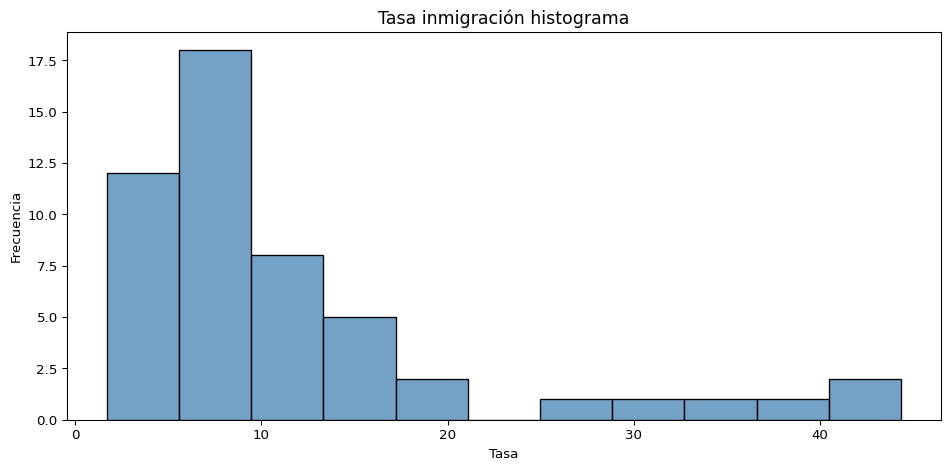

In [12]:
import seaborn
fig, ax = plt.subplots(1, figsize=(10, 5))

seaborn.histplot(
    comunas_final["tasa"],
    ax=ax,
    color="steelblue")

ax.set_title("Tasa inmigración histograma", fontsize=13)
ax.set_xlabel("Tasa")
ax.set_ylabel("Frecuencia")
plt.tight_layout()
plt.show()

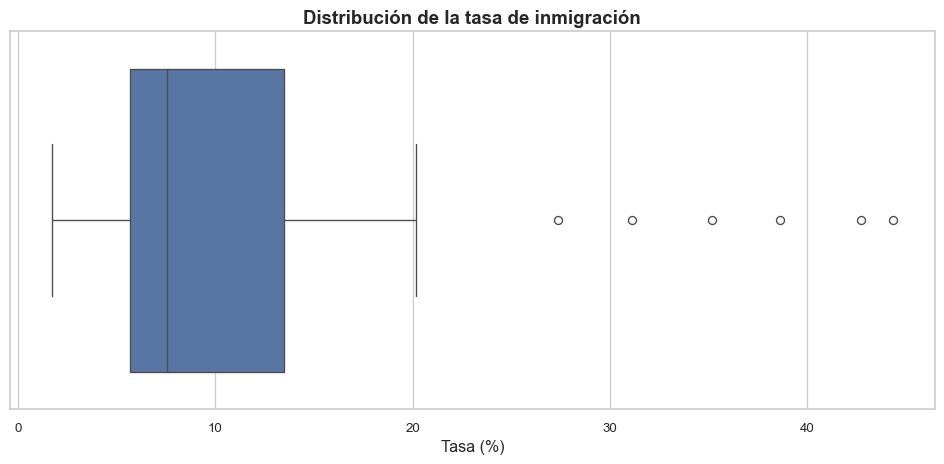

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# Estilo general
sns.set(style="whitegrid")

plt.figure(figsize=(10, 5))

# Boxplot
sns.boxplot(data=comunas_final, x="tasa", color="#4C72B0")

# Títulos y etiquetas
plt.title("Distribución de la tasa de inmigración", fontsize=14, weight='bold')
plt.xlabel("Tasa (%)", fontsize=12)
plt.ylabel("")  # opcional: quitar eje Y si no aporta

# Ajustes visuales
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

Cual es la comuna con mayor porcentaje de migrantes? Y la que tiene menor porcentaje? ¿Cuál es la mediana y media del porcentaje de migrantes en las comunas de la RM? ¿Qué nos dice esto sobre la distribución de migrantes en la región?

La comuna con mayor porcentaje de migración es "santiago", la que tiene menor porcentaje de inmigración es "pirque". La mediana de porcentaje es de un 7.56% y la media 11.61% de migrantes en las comunas de la RM. Esto nos dice que los migrantes están mas concentrados en las comunas urbanas con mayor población y menor tasa en las comunas mas rurales.

### Pregunta para reflexionar

Observa la distribución: ¿Es simétrica o asimétrica? ¿Tiene outliers?

La distribución es más o menos simétrica en las tasas inferiores al 20% y luego tiene varios outliers superiores al 30%. Esto puede ser que hay una distribución más o menos uniforme de migrantes, pero hay comunas específicas que hay una migración mucho mas masiva.


## PARTE 3: Mapas coropléticos con distintos clasificadores (20 minutos)



### 3.1 Primer vistazo: el mapa sin datos

Visualiza la geometria de la RM

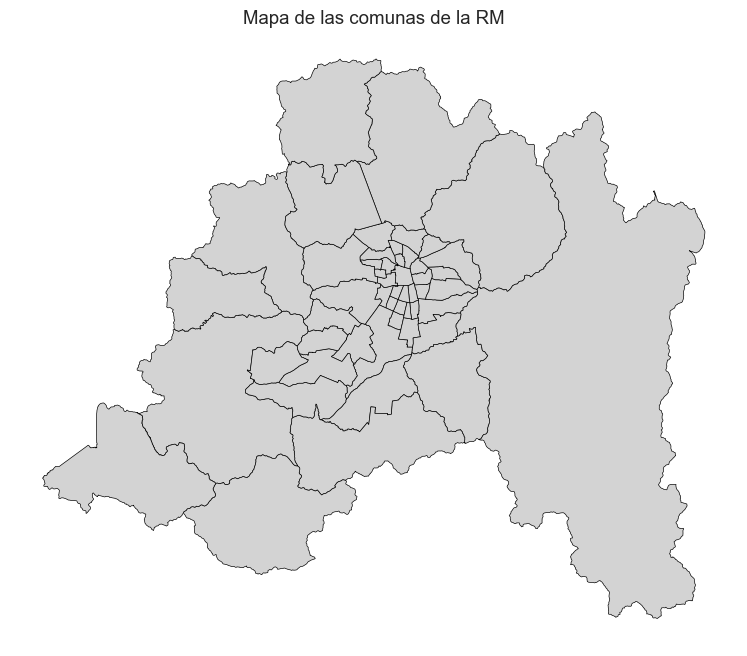

In [14]:
fig, ax = plt.subplots(1, figsize=(10, 7))
comunas_final.plot(
    ax=ax,
    edgecolor="black",
    facecolor="lightgray",
    linewidth=0.5
)
ax.set_title("Mapa de las comunas de la RM", fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()

Ahora crea un mapa de coropletas para visualizar el porcentaje de migrantes por comuna en la Región Metropolitana.

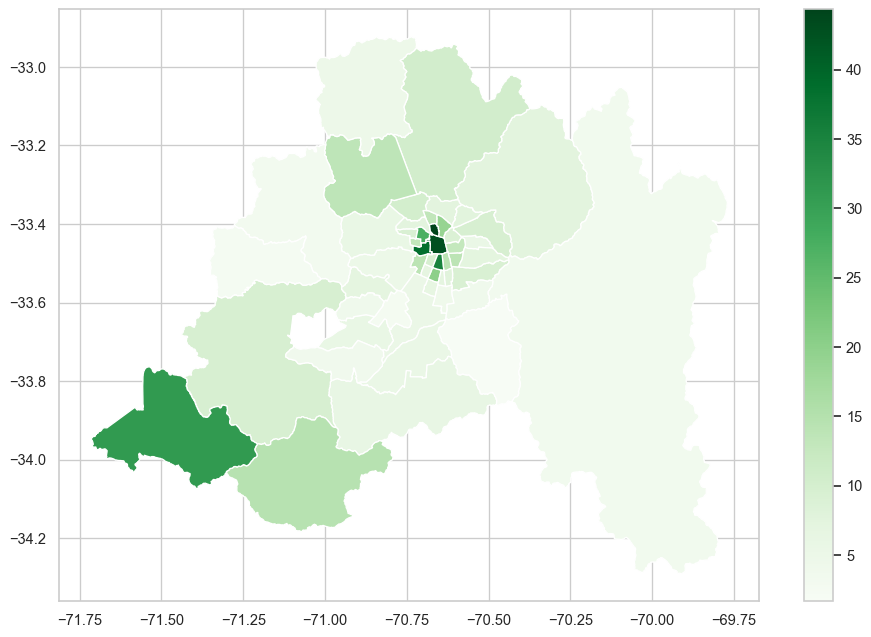

In [15]:
comunas_final.plot(column='tasa', legend=True, cmap='Greens')
plt.show()

### 3.2 Intervalos Iguales (k=5)

Recuerda: divide el rango total en **k partes de igual ancho**.


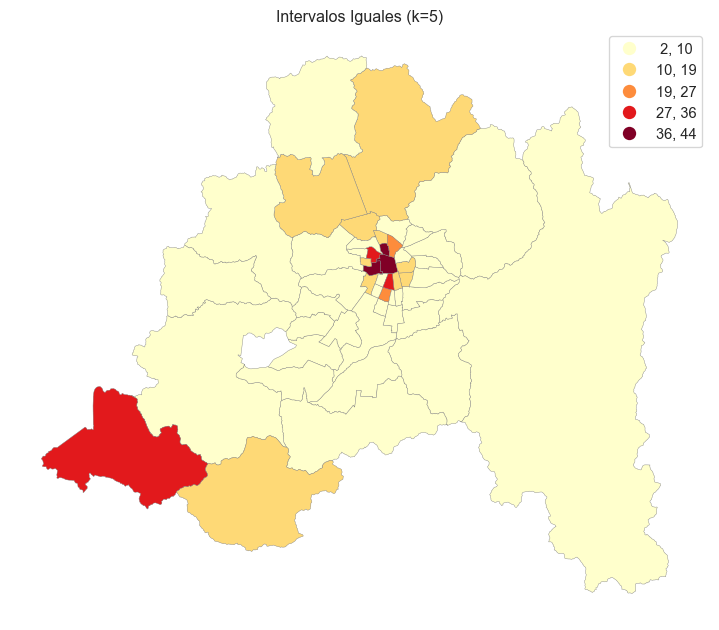

In [16]:
comunas_final.plot(
    column="tasa",
    scheme="EqualInterval",
    k=5,
    cmap="YlOrRd",
    legend=True,
    legend_kwds={"fmt": "{:.0f}"},
    edgecolor="gray",
    linewidth=0.3
)
plt.axis("off")
plt.title("Intervalos Iguales (k=5)")
plt.show()

### 3.3 Cuantiles (k=5)

Recuerda: cada clase tiene **aproximadamente el mismo número de comunas**.


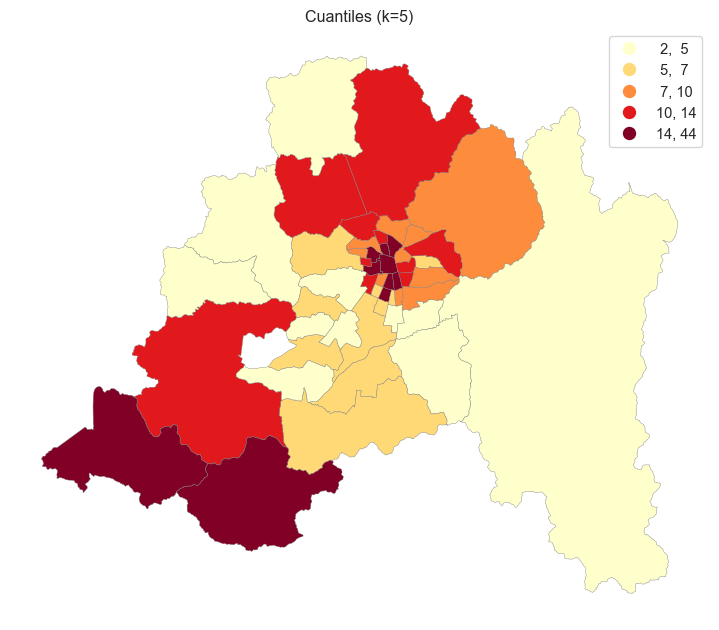

In [17]:
comunas_final.plot(
    column="tasa",
    scheme="Quantiles",
    k=5,
    cmap="YlOrRd",
    legend=True,
    legend_kwds={"fmt": "{:.0f}"},
    edgecolor="gray",
    linewidth=0.3
)
plt.axis("off")
plt.title("Cuantiles (k=5)")
plt.show()

### 3.4 Fisher-Jenks (k=5)

Recuerda: **minimiza la varianza intra-clase** usando programación dinámica. Es la clasificación **óptima** estadísticamente.


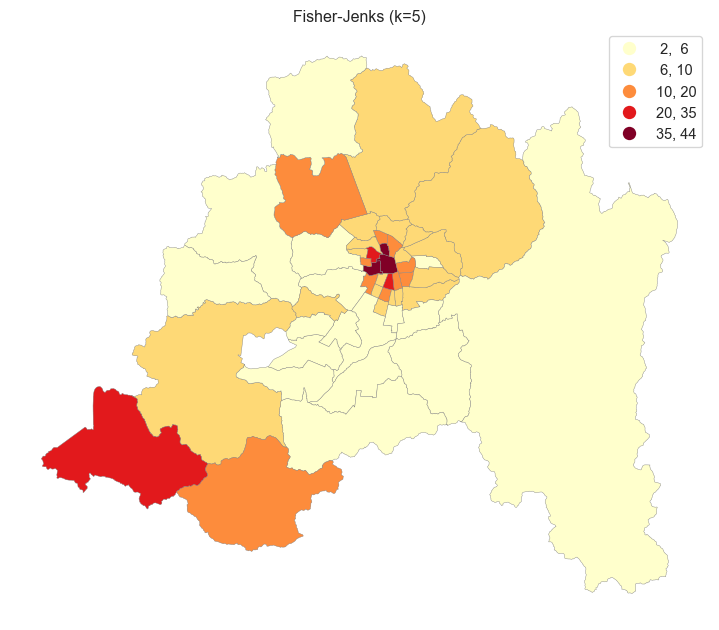

In [18]:
comunas_final.plot(
    column="tasa",
    scheme="FisherJenks",
    k=5,
    cmap="YlOrRd",
    legend=True,
    legend_kwds={"fmt": "{:.0f}"},
    edgecolor="gray",
    linewidth=0.3
)
plt.axis("off")
plt.title("Fisher-Jenks (k=5)")
plt.show()

### 3.5 Comparación lado a lado

Observa los tres mapas juntos. ¿Hay comunas cambian de color entre un clasificador y otro?


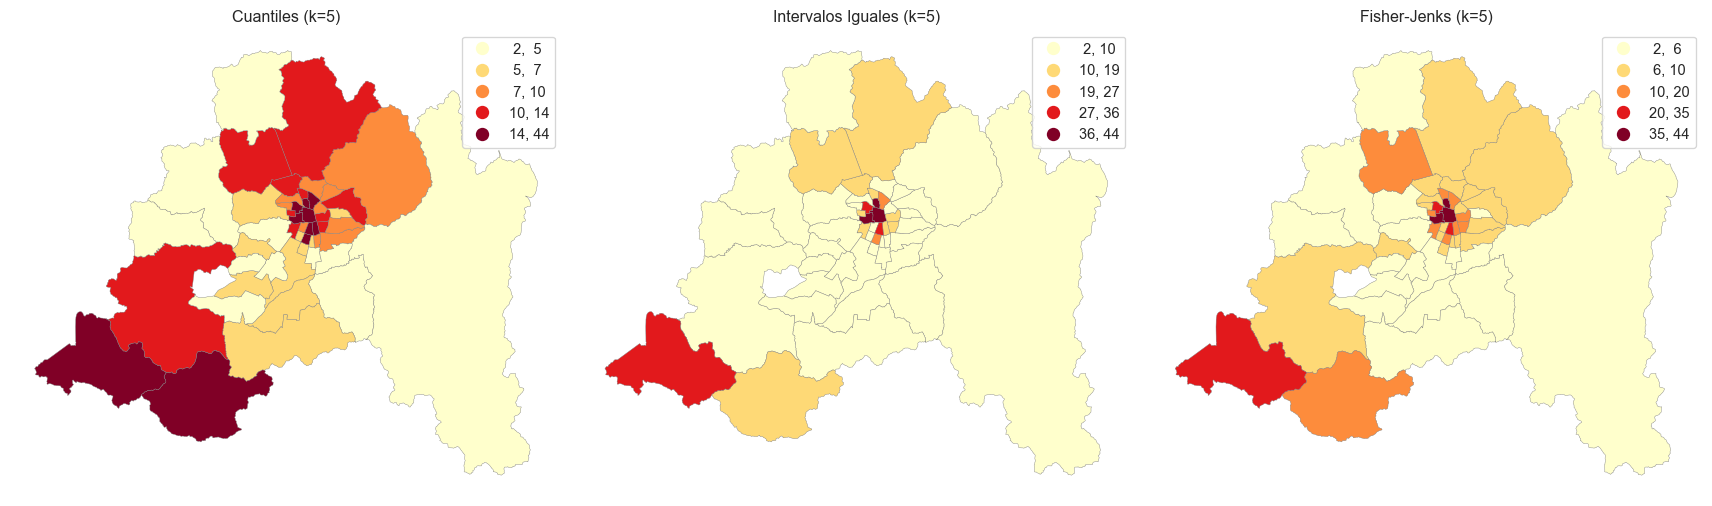

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

comunas_final.plot(
    column="tasa",
    scheme="Quantiles",
    k=5,
    cmap="YlOrRd",
    legend=True,
    legend_kwds={"fmt": "{:.0f}"},
    edgecolor="gray",
    linewidth=0.3,
    ax=axes[0]
)
axes[0].set_axis_off()
axes[0].set_title("Cuantiles (k=5)")

comunas_final.plot(
    column="tasa",
    scheme="EqualInterval",
    k=5,
    cmap="YlOrRd",
    legend=True,
    legend_kwds={"fmt": "{:.0f}"},
    edgecolor="gray",
    linewidth=0.3,
    ax=axes[1]
)
axes[1].set_axis_off()
axes[1].set_title("Intervalos Iguales (k=5)")

comunas_final.plot(
    column="tasa",
    scheme="FisherJenks",
    k=5,
    cmap="YlOrRd",
    legend=True,
    legend_kwds={"fmt": "{:.0f}"},
    edgecolor="gray",
    linewidth=0.3,
    ax=axes[2]
)
axes[2].set_axis_off()
axes[2].set_title("Fisher-Jenks (k=5)")

plt.tight_layout()
plt.show()

### 3.6 Comparación numérica: ADCM

¿Cuál tiene el menor ADCM? ¿Coincide con el mapa que visualmente te parece más informativo?


El mapa con menor ADCM es en el cual se utilizó Fisher-Jenks. Si coincide con el mapa que entrega mejor la información.

In [ ]:
tasa_limpia = comunas_final['tasa'].dropna()
fj5 = mapclassify.FisherJenks(tasa_limpia, k=5)
ei5 = mapclassify.EqualInterval(tasa_limpia, k=5)
q5 = mapclassify.Quantiles(tasa_limpia, k=5)

0     42.745545
1     13.863636
2      9.261364
3     13.303125
4      6.563580
5     38.615730
6      7.471429
7     44.346957
8     20.169474
9      9.263388
10     7.720690
11     4.364972
12     5.606818
13     9.686747
14     7.523387
15     6.776042
16    12.875532
17    13.987931
18     4.899135
19    12.821491
20     9.566316
21     7.261111
22     8.919014
23     5.782642
24    10.275686
25    27.375781
26    18.956000
27     7.515823
28    14.300000
29    35.197196
30     7.182927
31     7.564368
32     4.120525
33     1.700000
34     3.616667
35    10.483077
36    13.660769
37     4.750000
38     5.501515
39     5.692632
40     2.753333
41     6.068293
42     9.668182
43     3.276316
44     2.658333
45     5.843056
47     3.782857
48     7.100000
49     4.041250
50    14.650000
51    31.125000
Name: tasa, dtype: float64

In [26]:
# Agrupamos todos los clasificadores en una tupla para procesarlos juntos
class5 = (fj5, ei5, q5)

# Extraemos el ADCM de cada uno
print("ADCM por clasificador (menor = mejor ajuste):")
for c in sorted(class5, key=lambda x: x.adcm):
    print(f"  {c.name:25s}  ADCM = {c.adcm:>10,.0f}")

ADCM por clasificador (menor = mejor ajuste):
  FisherJenks                ADCM =         67
  EqualInterval              ADCM =         86
  Quantiles                  ADCM =        132


---
## PARTE 4: Análisis e interpretación (15 minutos)

### 4.1 Heatmap comparativo

Observa en qué comunas los tres clasificadores coinciden y en cuáles discrepan.


In [32]:
comunas_final.loc[tasa_limpia.index, 'Fisher-Jenks'] = fj5.yb
comunas_final.loc[tasa_limpia.index, 'Intervalos Iguales'] = ei5.yb
comunas_final.loc[tasa_limpia.index, 'Cuantiles'] = q5.yb

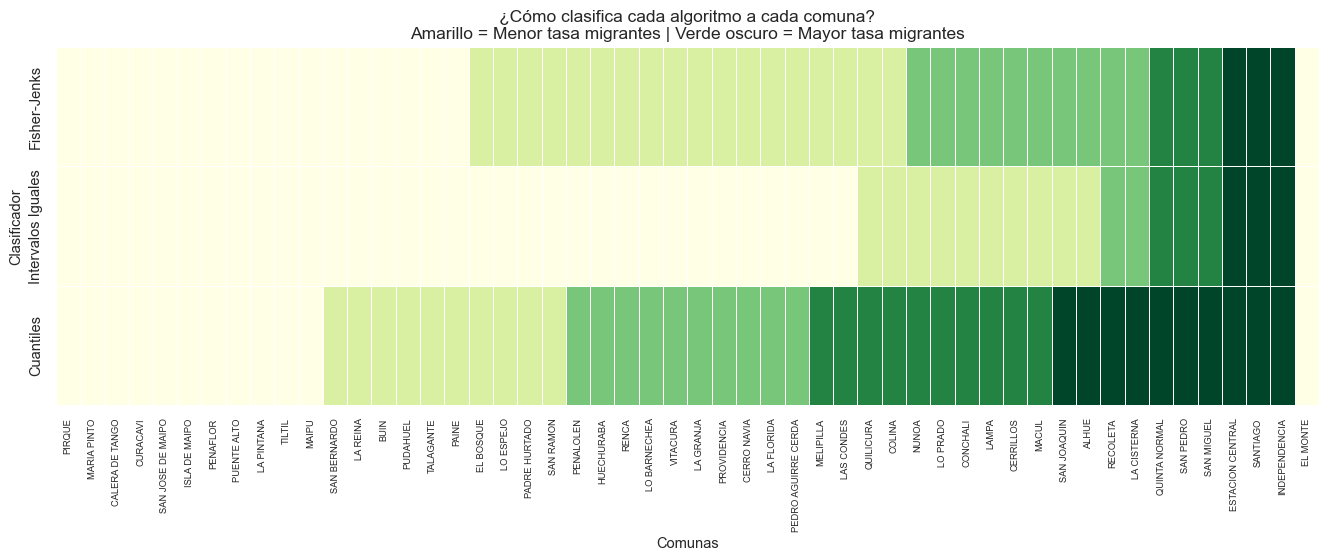

In [33]:
cols_clasif = ["Fisher-Jenks", "Intervalos Iguales", "Cuantiles"]

datos_heatmap = (
    comunas_final.set_index("COMUNA")
      .sort_values("tasa")
      [cols_clasif]
      .T
)

f, ax = plt.subplots(1, figsize=(14, 6))
seaborn.heatmap(
    datos_heatmap,
    cmap="YlGn",         # Paleta amarillo -> verde
    cbar=False,          # Sin barra de colores lateral
    ax=ax,
    linewidths=0.5,      # Líneas blancas entre celdas
    linecolor="white"
)
ax.set_xlabel("Comunas", fontsize=11)
ax.set_ylabel("Clasificador", fontsize=11)
ax.set_title(
    "¿Cómo clasifica cada algoritmo a cada comuna?\n"
    "Amarillo = Menor tasa migrantes | Verde oscuro = Mayor tasa migrantes",
    fontsize=13
)
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.show()

### 4.2 Preguntas de análisis

**Pregunta 1:** ¿Qué comunas concentran la mayor proporción de migrantes? ¿Coincide con lo que conoces de Santiago? ¿Por qué crees que estas comunas atraen más migración?


Estacion Central, Santiago e Independencia son las 3 comunas con mayor proporción de migrantes. Si creo que coincide sobre lo que conozco de Santiago. 

Creo que esas comunas tienen la mayor tasa de migración ya que se encuentra en el centro de la ciudad. Ademas cuentan con gran oferta de lugares para vivir.

**Pregunta 2:** Compara los tres mapas (Intervalos Iguales, Cuantiles, Fisher-Jenks). ¿En qué comunas los clasificadores "discrepan" más, es decir, las asignan a clases muy diferentes? ¿Por qué ocurre esto?


Existe gran diferencia en la clasificación de comunas con tasas medias-altas, como Melipilla, Las Condes, Providencia, entre otros. Esto ocurre por la matematica que utiliza cada algoritmo para construir los intervalos cuando existen valores extremos.

- En intervalos iguales el clasificador se ve sesgado por comunas con tasas muy altas. Por eso ocurre que comunas como Las Condes o Providencia queden en la categoría más baja.
- Cuando utilizamos cuantiles se fuerza a existir la misma cantidad de comunas por categoría. Ignorando los valores reales entre sí.
- Y para Fisher-Jenks al minimizar la varianza permite generar grupos más reales en base a los datos.

**Pregunta 3:** Si tuvieras que presentar estos datos en un informe para una política pública sobre integración de migrantes, ¿qué clasificador elegirías y por qué?


Si consideramos la misma cantidad de datos utilizaría Fisher-Jenks. Creemos que agrupa los datos de manera realista, mientras que el resto de clasificadores están más sesgados.


### Referencias

- Clase 5: Mapas Coropléticos (basada en Rey, Arribas-Bel y Wolf, 2020. *Geographic Data Science with Python*).
- Datos: [Censo 2024 - INE Chile](https://censo2024.ine.gob.cl/)
- Procesamiento original: [daniopitz/censo2024](https://github.com/daniopitz/censo2024)
